# 04 — 介电常数物理耦合模型（VOD ↔ LFMC），将训练集部分的数据构建VOD→LFMC的网络

本部分目标：
- 写出可拟合的前向模型：LFMC → εveg → εcanopy → VOD
- 用已有的 (VOD, LFMC, Hveg) 样本拟合参数（最小参数版本）
- 输出：拟合后的参数、以及预测/残差图

注意：
- 本 Notebook 不依赖所有辅助数据下载完成
- 只需要一个训练 DataFrame：包含 lfmc_pct, hveg_m, band, vod_obs


## 前置补充——物理链条解释

1:在不同极化的VOD下，冠层的介电常数可以进行联系。

Schmugge的形式
$$
VOD_{f,p} = (\frac{4{\pi}h_{veg}}{\lambda})Im(\sqrt{\varepsilon_{\text{can}}})
$$

Schmugge的改进形式
$$
VOD_{f,p} = (\frac{b_p . h_{veg}+a_p}{\lambda})Im(\sqrt{\varepsilon_{\text{can}}})
$$
- $h_{veg}$：冠层高度，m
- $\lambda$：m, f_{Hz} = f_{GHz}×10^9, c的单位为m/s，lambda_m = /frac{c}{f_{GHz}×10^9}

2:冠层理解为植被和空气的混合，如何从冠层（等效）介电常数转换为植被组分的介电常数

2.1 来自Schmugge 1990：幂律模型
$$
\varepsilon_{\text{can}}
=\left[(1-f)\cdot 1^{\beta}+f\,\varepsilon_{\text{veg}}^{\beta}\right]^{1/\beta}
=\left[1+f\left(\varepsilon_{\text{veg}}^{\beta}-1\right)\right]^{1/\beta}.
$$

其中：
- $f$：植被体积分数
- $\beta = 1$：线性介电常数混合
- $\beta = 1/2$：折射率/平方根混合（Birchak / refractive index mixing）
- $\beta = 1/3$：Looyenga 立方根混合

2.2 来自Ulaby：Polder–van Santen / de Loor推导
$$
\varepsilon_m=\varepsilon_h+\frac{v_i}{3}\left(\varepsilon_i-\varepsilon_h\right)\sum_{u=a,b,c}\frac{1}{1+A_u\left(\frac{\varepsilon_i}{\varepsilon^{*}}-1\right)}
$$

其中：

- $\varepsilon_h$：宿主介电常数（空气≈1）
- $\varepsilon_i$：夹杂介电常数（植被组分 $\varepsilon_{\text{veg}}$）
- $v_i$：夹杂植被体积分数（对应2.1的 $f$）
- $A_u$：去极化因子（形状/长短轴决定，球体时 $A_a=A_b=A_c=1/3$）
- $\varepsilon^{*}$：夹杂周围“局部环境”的等效介电常数（de Loor 对粒子相互作用的处理）
  - 小体积分数（＜0.1）时可取 $\varepsilon^{*}=\varepsilon_h$
  - 体积分数大、相互作用强时可取 $\varepsilon^{*}=\varepsilon_m$
  - 端点行为：
    - $v_i\to 0 \Rightarrow \varepsilon_m\to \varepsilon_h$
    - $v_i\to 1 \Rightarrow \varepsilon_m\to \varepsilon_i$（当 $\varepsilon^{*}=\varepsilon_m$ 时满足）



3:植被介电常数转化为LFMC

Ulaby 1987的实验室推导：
文献给出在室温条件下，将植被组分介电常数 \(\varepsilon_{\text{veg}}\) 表达为 \(M_g\) 的模型为：

$$
\varepsilon_{\text{veg}}(f)=\varepsilon_r(M_g)+v_{fw}(M_g)\,\varepsilon_f(f)+v_b(M_g)\,\varepsilon_b(f)
$$

其中 \(\varepsilon_r(M_g)\)、自由水体积分数 \(v_{fw}(M_g)\) 以及“骨架+束缚水”混合体体积分数 \(v_b(M_g)\) 的经验关系为（式 (14)–(16)）：

$$
\varepsilon_r(M_g)=1.7-0.74\,M_g+6.16\,M_g^2
\tag{14}
$$

$$
v_{fw}(M_g)=M_g\left(0.55\,M_g-0.076\right)
\tag{15}
$$

$$
v_b(M_g)=\frac{4.64\,M_g}{1+7.36\,M_g^2}
\tag{16}
$$

并给出导电率参数（式 (17)）：
$$ \sigma \approx 1.27 $$


束缚水-骨架混合体介电谱（Cole–Cole 形式）

$$
\varepsilon_b(f)=2.9+\frac{55.0}{1+\left(j\,\frac{f}{0.18}\right)^{0.5}}
\tag{8}
$$

自由水介电谱（Debye + 导电项，室温近似写法：T=22℃，S=10%）

$$
\varepsilon_f(f)\approx
4.9+\frac{75.0}{1+j\,f/18}
-\;j\,\frac{18\,\sigma}{f}
$$

引申：温度的变化，主要是影响自由水部分的介电常数

文中给出的 Debye 拆分形式为：
$$
\varepsilon_f'(f,T)=\varepsilon_\infty(T)+\frac{\varepsilon_s(T)-\varepsilon_\infty(T)}{1+\left(\frac{f}{f_0(T)}\right)^2}
$$


$$
\varepsilon_f''(f,T)=\frac{\left(\frac{f}{f_0(T)}\right)\left(\varepsilon_s(T)-\varepsilon_\infty(T)\right)}{1+\left(\frac{f}{f_0(T)}\right)^2}
+\frac{\sigma}{2\pi\varepsilon_0 f}
$$



<!-- -->采用复介电常数记号:
$$\varepsilon_f=\varepsilon_f'-j\varepsilon_f''$$
，可合并为等价的复数形式：
$$
\varepsilon_f(f,T)=\varepsilon_\infty(T)+\frac{\varepsilon_s(T)-\varepsilon_\infty(T)}{1+j\,\dfrac{f}{f_0(T)}}
-\;j\,\frac{\sigma}{2\pi\varepsilon_0 f}
$$

其中弛豫频率与弛豫时间关系为：
$$
f_0(T)=\frac{1}{2\pi\tau(T)}
$$

很多情况下取高频极限项近似为常数：
$$
\varepsilon_\infty(T)\approx 4.9
$$

则：
$$
\varepsilon_f(f,T)
\approx
4.9
+
\frac{\varepsilon_s(T)-4.9}{1+j\,\dfrac{f}{f_0(T)}}
-\;j\,\frac{\sigma}{2\pi\varepsilon_0 f}
$$

两个物理机制模糊的未知量：
- $\varepsilon_s(T)$：温度T下的静态介电常数，在0℃为87.1，22°约为80（随温度升高总体非线性减小）
- $f_0(T)$：介电弛豫频率，在0℃约为9GHz，在20℃约为17GHz（随温度升高非线性单调增加）


$\varepsilon_s(T)$：Malmberg & Maryott（NIST, 1956）：
$$
\varepsilon_s(T)=87.740-0.400081\,T+9.398\times 10^{-4}\,T^2-1.410\times 10^{-6}\,T^3
$$


$f_0(T)$：Ellison（2007）
$$
\tau_1(T)=c_1\exp\!\left(\frac{d_1}{T+t_c}\right)
$$

$$
c_1=1.382264\times 10^{-13}\ \text{s},\quad
d_1=652.7648,\quad
t_c=133.1383
$$

$$
f_0(T)=\frac{1}{2\pi\,\tau_1(T)}
$$

4. Mg转化为可燃物含水率LFMC

$$
LFMC = (\frac{M_g}{1-M_g}).100
$$


最后请注意，Schmugge的链条是设置植被虚部为正，而Ulaby的植被介电模型设置的是虚部为负，参考实际情况，我们建议使用虚部为负的符号约定，并且修改vod_forward.py的写法(对虚部直接取绝对值)，使其能够正常地计算。

## 前置补充——神经网络中的耦合物理链条解释（用于物理一致性损失）

目标：网络输出的 $\widehat{\mathrm{LFMC}}$ 不仅要拟合真值（LFMC），还应当在物理链条上与观测到的 H 极化 VOD（这里用 $\tau_{b,H}$ 代表观测 VOD/光学厚度）保持一致。

----------------------------------------

1. 物理前向链条（LFMC $\rightarrow$ $\varepsilon_{\mathrm{veg}}$ $\rightarrow$ $\varepsilon_{\mathrm{can}}$ $\rightarrow$ VOD）

我们对每条观测（像元 $i$、时刻 $t$、波段 $b$）建立如下映射。

(1) LFMC $\rightarrow$ 植被复介电常数 $\varepsilon_{\mathrm{veg}}$（Ulaby 1987）

复介电常数约定采用： $$ \varepsilon = \varepsilon' - j\,\varepsilon'', \quad \varepsilon'' \ge 0, \quad \Im(\varepsilon)\le 0 . $$

先把 LFMC(%) 转成重力含水率 $M_g \in [0,1)$： $$ \mathrm{LFMC} = 100\cdot \frac{M_g}{1-M_g} \quad \Rightarrow \quad M_g = \frac{\mathrm{LFMC}}{\mathrm{LFMC}+100}. $$

Ulaby 的经验形式把植被介电常数写为三部分叠加： $$ \widehat{\varepsilon}_{\mathrm{veg}}(i,t,b)= \varepsilon_r(M_g) + v_{fw}(M_g)\,\varepsilon_f(f_b, T(i,t)) + v_b(M_g)\,\varepsilon_b(f_b). $$

其中：
- $M_g$：重力含水率（由 LFMC 换算得到）
- $\varepsilon_r(M_g)$：骨架经验项
- $v_{fw}(M_g)$：自由水体积分数权重
- $v_b(M_g)$：束缚水/骨架混合体体积分数权重
- $\varepsilon_f(f_b,T)$：自由水介电谱（随温度变化）
- $\varepsilon_b(f_b)$：束缚水介电谱（Cole–Cole 型）
- $f_b$：波段中心频率（GHz 或 Hz，需与实现保持一致）
- $T(i,t)$：温度（由 LST 转换而来）

温度输入：数据列为 $\mathrm{LST}(i,t)$（单位 K），转换为摄氏： $$ T(^{\circ}\mathrm{C}) = \mathrm{LST}(K) - 273.15 . $$

(2) $\varepsilon_{\mathrm{veg}}$ + 冠层植被体积分数 $v_{\mathrm{veg}}$ $\rightarrow$ 冠层等效介电常数 $\varepsilon_{\mathrm{can}}$

将冠层视为“空气 + 植被组分”的混合物： $$ \widehat{\varepsilon}_{\mathrm{can}}(i,t,b) = \mathcal{M}\!\Big( \varepsilon_{\mathrm{air}}, \widehat{\varepsilon}_{\mathrm{veg}}(i,t,b), \widehat{v}_{\mathrm{veg}}(i,t) \Big), \quad \varepsilon_{\mathrm{air}}\approx 1-0j. $$

其中：
- $\widehat{v}_{\mathrm{veg}}(i,t)\in(0,1)$：冠层植被体积分数（vegf，隐含变量，可由网络结构分支输出或作为待估参数）
- $\mathcal{M}(\cdot)$：混合模型（Bruggeman / 幂律 / de Loor 等）

(3) $\varepsilon_{\mathrm{can}} \rightarrow$ VOD（Schmugge 型，H 极化，无 a,b 校准项）

本实验只使用 H 极化，并采用不含 $(a,b)$ 的简化形式： $$ \widehat{\mathrm{VOD}}_{b,H}(i,t) = \frac{4\pi\,h_{\mathrm{veg}}(i,t)}{\lambda_b}\, \Im\!\Big(\sqrt{\widehat{\varepsilon}_{\mathrm{can}}(i,t,b)}\Big). $$

其中：
- $h_{\mathrm{veg}}(i,t)$：冠层高度（m，数据列 canopy_height）
- $\lambda_b = \frac{c}{f_b}$：波长（m）
- $\Im(\cdot)$：虚部
- $\sqrt{\cdot}$：复数主值平方根（principal branch）

观测对齐：数据中把 H 极化的观测 VOD/光学厚度记为： $$ \mathrm{VOD}_{\mathrm{Ku},H}=\tau_{\mathrm{Ku},H},\quad \mathrm{VOD}_{\mathrm{X},H}=\tau_{\mathrm{X},H},\quad \mathrm{VOD}_{\mathrm{C},H}=\tau_{\mathrm{C},H}. $$  
对应数据列：tau_Ku_H, tau_X_H, tau_C_H。

----------------------------------------

2. 物理一致性损失（Physics Consistency Loss）

对样本 $(i,t)$，在频段集合 $\mathcal{B}=\{\mathrm{Ku},\mathrm{X},\mathrm{C}\}$ 上定义： $$ \mathcal{L}_{\mathrm{phys}}(i,t) = \frac{1}{|\mathcal{B}|} \sum_{b\in\mathcal{B}} \rho\!\Big( \widehat{\mathrm{VOD}}_{b,H}(i,t) - \mathrm{VOD}_{b,H}(i,t) \Big). $$

其中 $\rho(\cdot)$ 为鲁棒误差函数，常用：
- 平方误差：$\rho(x)=x^2$
- Huber：$\rho(x)=\mathrm{Huber}(x)$

如果存在缺测（某个 band 的 $\tau$ 为空），使用 mask 去掉该项： $$ \mathcal{L}_{\mathrm{phys}}(i,t) = \frac{1}{\sum_{b\in\mathcal{B}} m_b(i,t)} \sum_{b\in\mathcal{B}} m_b(i,t)\, \rho\!\Big( \widehat{\mathrm{VOD}}_{b,H}(i,t) - \mathrm{VOD}_{b,H}(i,t) \Big), \quad m_b(i,t)\in\{0,1\}. $$

----------------------------------------

3. 总损失（监督 + 物理约束 + 结构稳定）

训练时一般组合： $$ \mathcal{L} = \mathcal{L}_{\mathrm{sup}} + \lambda_{\mathrm{phys}}\,\mathcal{L}_{\mathrm{phys}} + \lambda_{\mathrm{stable}}\,\mathcal{L}_{\mathrm{stable}}. $$

监督损失（LFMC 真值）： $$ \mathcal{L}_{\mathrm{sup}} = \rho\!\Big( \widehat{\mathrm{LFMC}}(i,t) - \mathrm{LFMC}(i,t) \Big). $$  
真值列：lfmc_pct。

结构稳定性（可选，用于让结构隐变量在同像元随时间缓变）： $$ \mathcal{L}_{\mathrm{stable}} = \frac{1}{T_i}\sum_{t} \Big( \widehat{s}(i,t) - \overline{\widehat{s}}(i) \Big)^2, \quad \overline{\widehat{s}}(i)=\frac{1}{T_i}\sum_t \widehat{s}(i,t). $$

其中 $\widehat{s}(i,t)$ 可取网络输出的 $\widehat{v}_{\mathrm{veg}}(i,t)$，或结构分支的低维表示。

----------------------------------------

4. 变量与数据字段对照

符号 | 含义 | 数据/配置来源
--- | --- | ---
$\mathrm{LFMC}(i,t)$ | 真值 LFMC(%) | lfmc_pct
$\widehat{\mathrm{LFMC}}(i,t)$ | 网络预测 LFMC | 模型输出
$\mathrm{LST}(i,t)$ | 地表温度 (K) | lst
$T(i,t)$ | 温度 (°C) | lst - 273.15
$h_{\mathrm{veg}}(i,t)$ | 冠层高度 (m) | canopy_height
$\mathrm{VOD}_{b,H}(i,t)$ | 观测 H 极化 VOD/光学厚度 | tau_Ku_H, tau_X_H, tau_C_H
$f_b$ | 频率 | configs/physics.yaml 的 bands_hz
$\lambda_b$ | 波长 (m) | $\lambda=c/f$
$\widehat{\varepsilon}_{\mathrm{veg}}$ | 植被复介电常数 | vegetation_dielectric (含温度)
$\widehat{\varepsilon}_{\mathrm{can}}$ | 冠层等效复介电常数 | mixing.* 混合模型
$\widehat{v}_{\mathrm{veg}}$ | 冠层植被体积分数（vegf） | 隐含变量（结构分支输出或待估参数）
$\lambda_{\mathrm{phys}}$ | 物理一致性权重 | 训练配置
$\lambda_{\mathrm{stable}}$ | 稳定性权重 | 训练配置


## 前置工作——模型有效性的检查：使用LFMC→VOD的前向过程模拟，分析介电混合模型的有效性

C:\Users\Ronin\AppData\Local\Temp\ipykernel_5132\1190776266.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("h_bin", as_index=False)


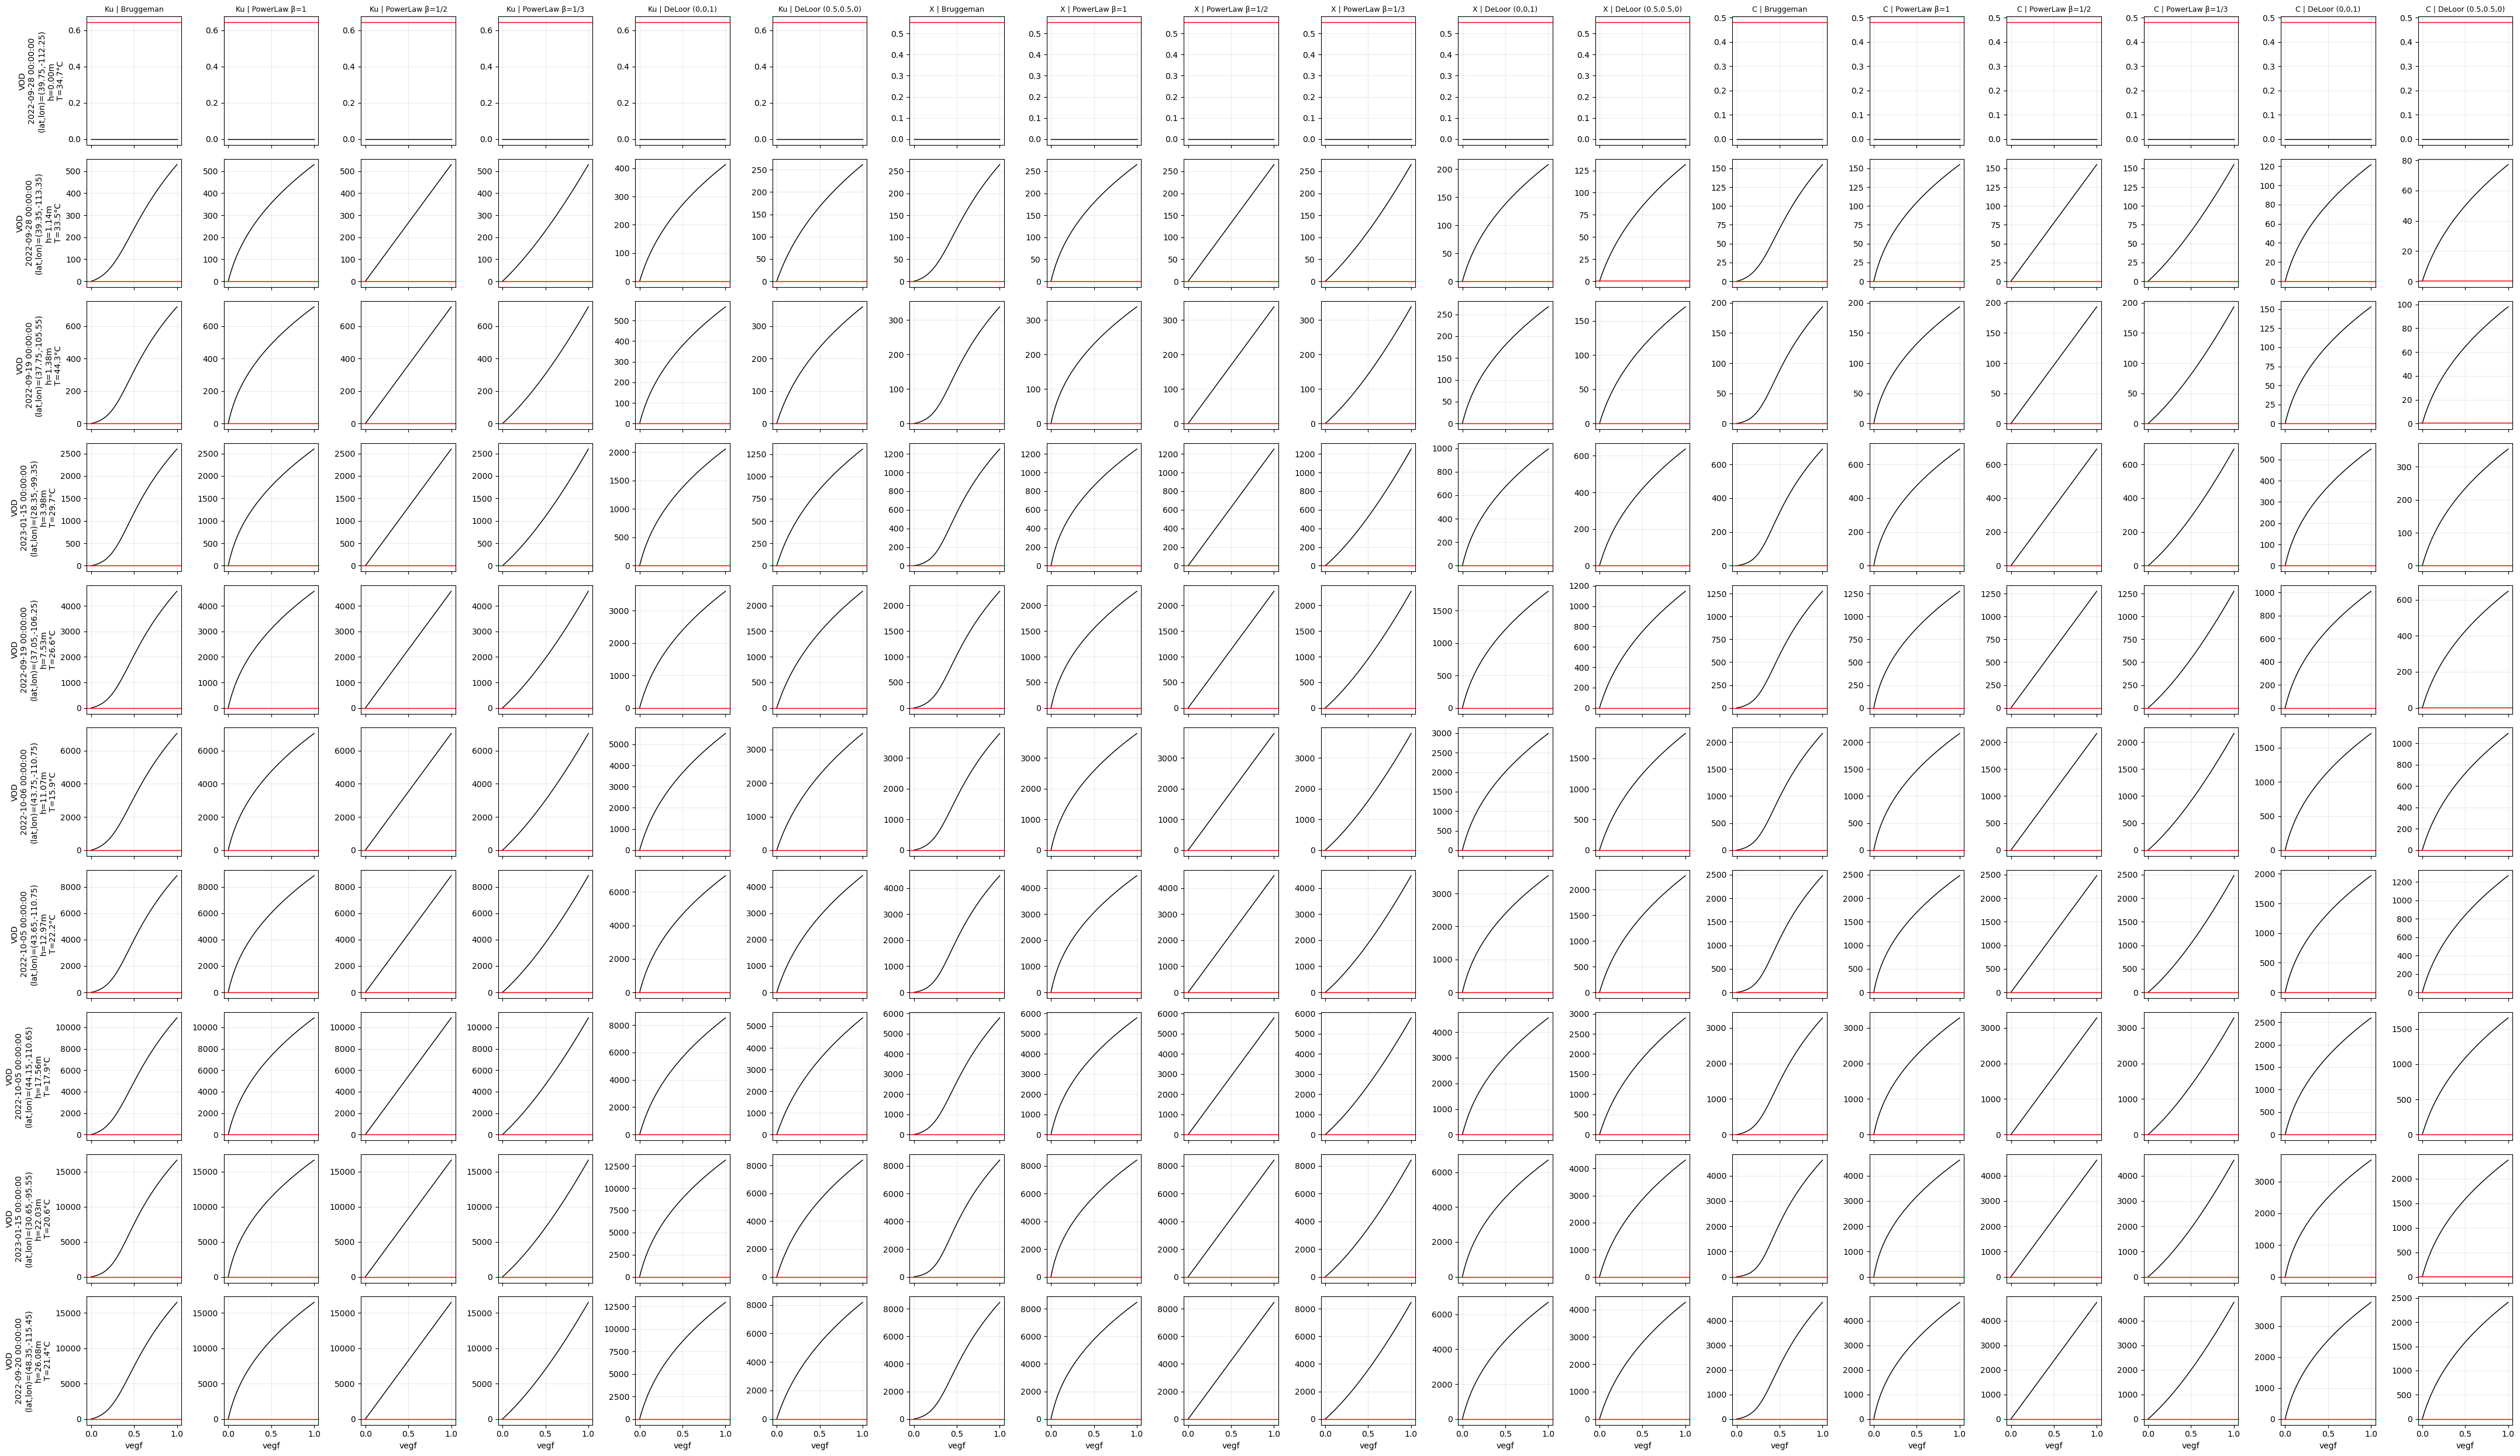

Saved figure to: D:\Python\jupyter\jupyter\LFMCRegressor\figs\lfmc_to_vod_vegf_10x18_posImagAssump_tempLst.png


In [1]:
# --- 单元：10x18 拼图（3 bands × (Bruggeman + 3 betas + 2 de loor)）
# --- 使用温度列 lst（正号约定/虚部为正假设），并保存到 /figs，纵轴固定 0-4 ---

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

# =========================
# 0) 路径与导入（绕过 function.physics.__init__.py）
# =========================
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD

PHYSICS_DIR = PROJECT_ROOT / "function" / "physics"
sys.path.insert(0, str(PHYSICS_DIR))

import constant
import mixing
import vegetation_dielectric
import vod_forward

# 输出目录（与 notebooks 平行）
FIG_DIR = PROJECT_ROOT / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 突出“正号假设/虚部为正”的文件名
OUT_PATH = FIG_DIR / "lfmc_to_vod_vegf_10x18_posImagAssump_tempLst.png"

# =========================
# 1) 读取 YAML（configs/physics.yaml）
# =========================
cfg_path = PROJECT_ROOT / "configs" / "physics.yaml"
with open(cfg_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

phy = cfg["physics"]
bands_hz = phy["bands_hz"]                 # {"C":..., "X":..., "Ku":...}
vod_cal = phy["vod_calibration"]           # per band: {"a":..., "b":...}
veg_eps_model = phy["vegetation_dielectric"]["model"]

# =========================
# 2) 读取 parquet
# =========================
parquet_path = r"G:\data\Globe LFMC\processed\lfmc_base_0p1.parquet"
df = pd.read_parquet(parquet_path)

need_cols = ["row", "col", "canopy_height", "lfmc_pct", "tau_Ku_H", "tau_X_H", "tau_C_H", "lst"]
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise KeyError(f"Parquet 缺少必要列: {missing}")

# 时间列自动识别（用于标注）
time_candidates = [
    "time", "date", "datetime", "timestamp",
    "obs_time", "acq_time", "acq_datetime", "acquisition_time",
    "t", "dt"
]
time_col = next((c for c in time_candidates if c in df.columns), None)

# 三波段H极化 tau + lfmc + canopy_height + row/col + lst 均不为空
df_valid = df.dropna(subset=need_cols).copy()

# 像元ID
df_valid["pix_id"] = df_valid["row"].astype(int).astype(str) + "_" + df_valid["col"].astype(int).astype(str)

# 至少2次观测（时序像元）
pix_stat = (
    df_valid.groupby("pix_id", sort=False)
    .agg(
        n_obs=("lfmc_pct", "size"),
        h_mean=("canopy_height", "mean"),
        row=("row", "first"),
        col=("col", "first"),
    )
    .reset_index()
)
pix_stat = pix_stat[pix_stat["n_obs"] >= 2].copy()
if len(pix_stat) < 10:
    raise ValueError(f"满足'至少2次观测且三波段tau都非空且lst非空'的像元不足10个：当前 {len(pix_stat)} 个")

# =========================
# 3) 选10个代表性像元（覆盖不同冠层高度）
# =========================
pix_stat = pix_stat.sort_values(["h_mean", "n_obs"], ascending=[True, False]).reset_index(drop=True)

try:
    pix_stat["h_bin"] = pd.qcut(pix_stat["h_mean"], q=10, duplicates="drop")
except ValueError:
    pix_stat["h_bin"] = pd.cut(pix_stat["h_mean"], bins=10)

chosen = (
    pix_stat.sort_values(["h_bin", "n_obs"], ascending=[True, False])
    .groupby("h_bin", as_index=False)
    .head(1)
)

# 不足10个就按 n_obs 补齐
if len(chosen) < 10:
    remaining = pix_stat[~pix_stat["pix_id"].isin(chosen["pix_id"])].sort_values("n_obs", ascending=False)
    chosen = pd.concat([chosen, remaining.head(10 - len(chosen))], ignore_index=True)

chosen = chosen.head(10).reset_index(drop=True)

# =========================
# 4) 每像元选 1 条代表观测（有时间列则选最新）
# =========================
records = []
for _, r in chosen.iterrows():
    sub = df_valid[df_valid["pix_id"] == r["pix_id"]].copy()
    if time_col is not None:
        sub = sub.sort_values(time_col)
        rec = sub.iloc[-1]
    else:
        rec = sub.iloc[0]
    records.append(rec)

rec_df = pd.DataFrame(records).reset_index(drop=True)

# =========================
# 5) row/col -> lat/lon（0-base）
# =========================
def rowcol_to_latlon(row0, col0):
    lat = 89.95 - 0.1 * float(row0)
    lon = -179.95 + 0.1 * float(col0)
    return round(lat, 2), round(lon, 2)

# lst -> temp_c（自动判断 K/°C）
def lst_to_temp_c(lst_val: float) -> float:
    # 常见 LST 如果是 Kelvin：约 250~330；如果是 Celsius：约 -30~60
    return lst_val - 273.15 if lst_val > 200 else lst_val

# =========================
# 6) 前向模拟 + 绘图（10x18），纵轴固定 0-4
# =========================
vegf = np.round(np.arange(0.0, 1.0 + 1e-12, 0.01), 2)

bands = ["Ku", "X", "C"]
tau_cols = {"Ku": "tau_Ku_H", "X": "tau_X_H", "C": "tau_C_H"}

mix_cases = [
    ("Bruggeman", ("bruggeman", None)),
    ("PowerLaw β=1", ("power", 1.0)),
    ("PowerLaw β=1/2", ("power", 0.5)),
    ("PowerLaw β=1/3", ("power", 1.0/3.0)),
    ("DeLoor (0,0,1)", ("deloor", (0.0, 0.0, 1.0))),
    ("DeLoor (0.5,0.5,0)", ("deloor", (0.5, 0.5, 0.0))),
]

n_rows = 10
n_cols = len(bands) * len(mix_cases)  # 18

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4*n_cols, 2.5*n_rows), sharex=True)

# 顶部列标题
col_titles = []
for b in bands:
    for m in mix_cases:
        col_titles.append(f"{b} | {m[0]}")
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=9)

for i in range(n_rows):
    rec = rec_df.iloc[i]
    row0 = int(rec["row"])
    col0 = int(rec["col"])
    lat, lon = rowcol_to_latlon(row0, col0)

    lfmc = float(rec["lfmc_pct"])
    hveg = float(rec["canopy_height"])

    lst_val = float(rec["lst"])
    temp_c = lst_to_temp_c(lst_val)

    if time_col is not None:
        tstr = str(pd.to_datetime(rec[time_col]))
    else:
        tstr = "NA"

    # 每行第一列 y轴：VOD + 文字（时间/经纬度/冠层高/温度）
    ylab = f"VOD\n{tstr}\n(lat,lon)=({lat},{lon})\nh={hveg:.2f}m\nT={temp_c:.1f}°C"

    for bi, band in enumerate(bands):
        freq_hz = float(bands_hz[band])
        freq_ghz = freq_hz / 1e9
        wl = constant.wavelength_from_freq(freq_hz)

        a = float(vod_cal[band]["a"])
        b = float(vod_cal[band]["b"])

        vod_obs = float(rec[tau_cols[band]])  # 红线：观测 tau_*_H

        # LFMC -> eps_veg（complex），这次传入温度（自由水介电常数会随温度变）
        eps_veg = vegetation_dielectric.epsilon_veg_from_lfmc(
            lfmc_pct=np.array([lfmc], dtype=float),
            f_ghz=np.array([freq_ghz], dtype=float),
            model=veg_eps_model,
            temp_c=np.array([temp_c], dtype=float),
        )[0]

        for mi, (mname, mcase) in enumerate(mix_cases):
            ax = axes[i, bi*len(mix_cases) + mi]

            tag, param = mcase

            if tag == "bruggeman":
                eps_can = np.array([
                    mixing.bruggeman_mix(
                        eps_components=np.array([1.0 + 0.0j, eps_veg], dtype=np.complex128),
                        fracs=np.array([1.0 - float(v), float(v)], dtype=float),
                        init=1.2 + 0.01j
                    )
                    for v in vegf
                ], dtype=np.complex128)

            elif tag == "power":
                beta = float(param)
                eps_can = mixing.power_law_air_veg(eps_veg=eps_veg, vegf=vegf, beta=beta)

            else:  # deloor
                Aa, Ab, Ac = param
                eps_can = np.array([
                    mixing.de_loor_pvs_forward(
                        eps_host=1.0 + 0.0j,
                        eps_incl=eps_veg,
                        vegf=float(v),
                        Aa=float(Aa), Ab=float(Ab), Ac=float(Ac),
                        eps_star=None
                    )
                    for v in vegf
                ], dtype=np.complex128)

            vod_pred = vod_forward.vod_from_eps_canopy(
                eps_canopy=eps_can,
                wavelength_m=wl,
                hveg_m=np.full_like(vegf, hveg, dtype=float),
                a=a, b=b
            )

            ax.plot(vegf, vod_pred, color="k", linewidth=1.05)
            ax.axhline(vod_obs, color="r", linewidth=1.05)

            if i == n_rows - 1:
                ax.set_xlabel("vegf")

            if (bi*len(mix_cases) + mi) == 0:
                ax.set_ylabel(ylab)
            else:
                ax.set_ylabel("")

            ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {OUT_PATH}")


### 结论：原始公式确实存在严重的不匹配的问题（Schmugge的公式有问题）

## 分析介电常数部分的数值量

### 冠层介电常数虚部

C:\Users\Ronin\AppData\Local\Temp\ipykernel_5132\1926329811.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("h_bin", as_index=False)


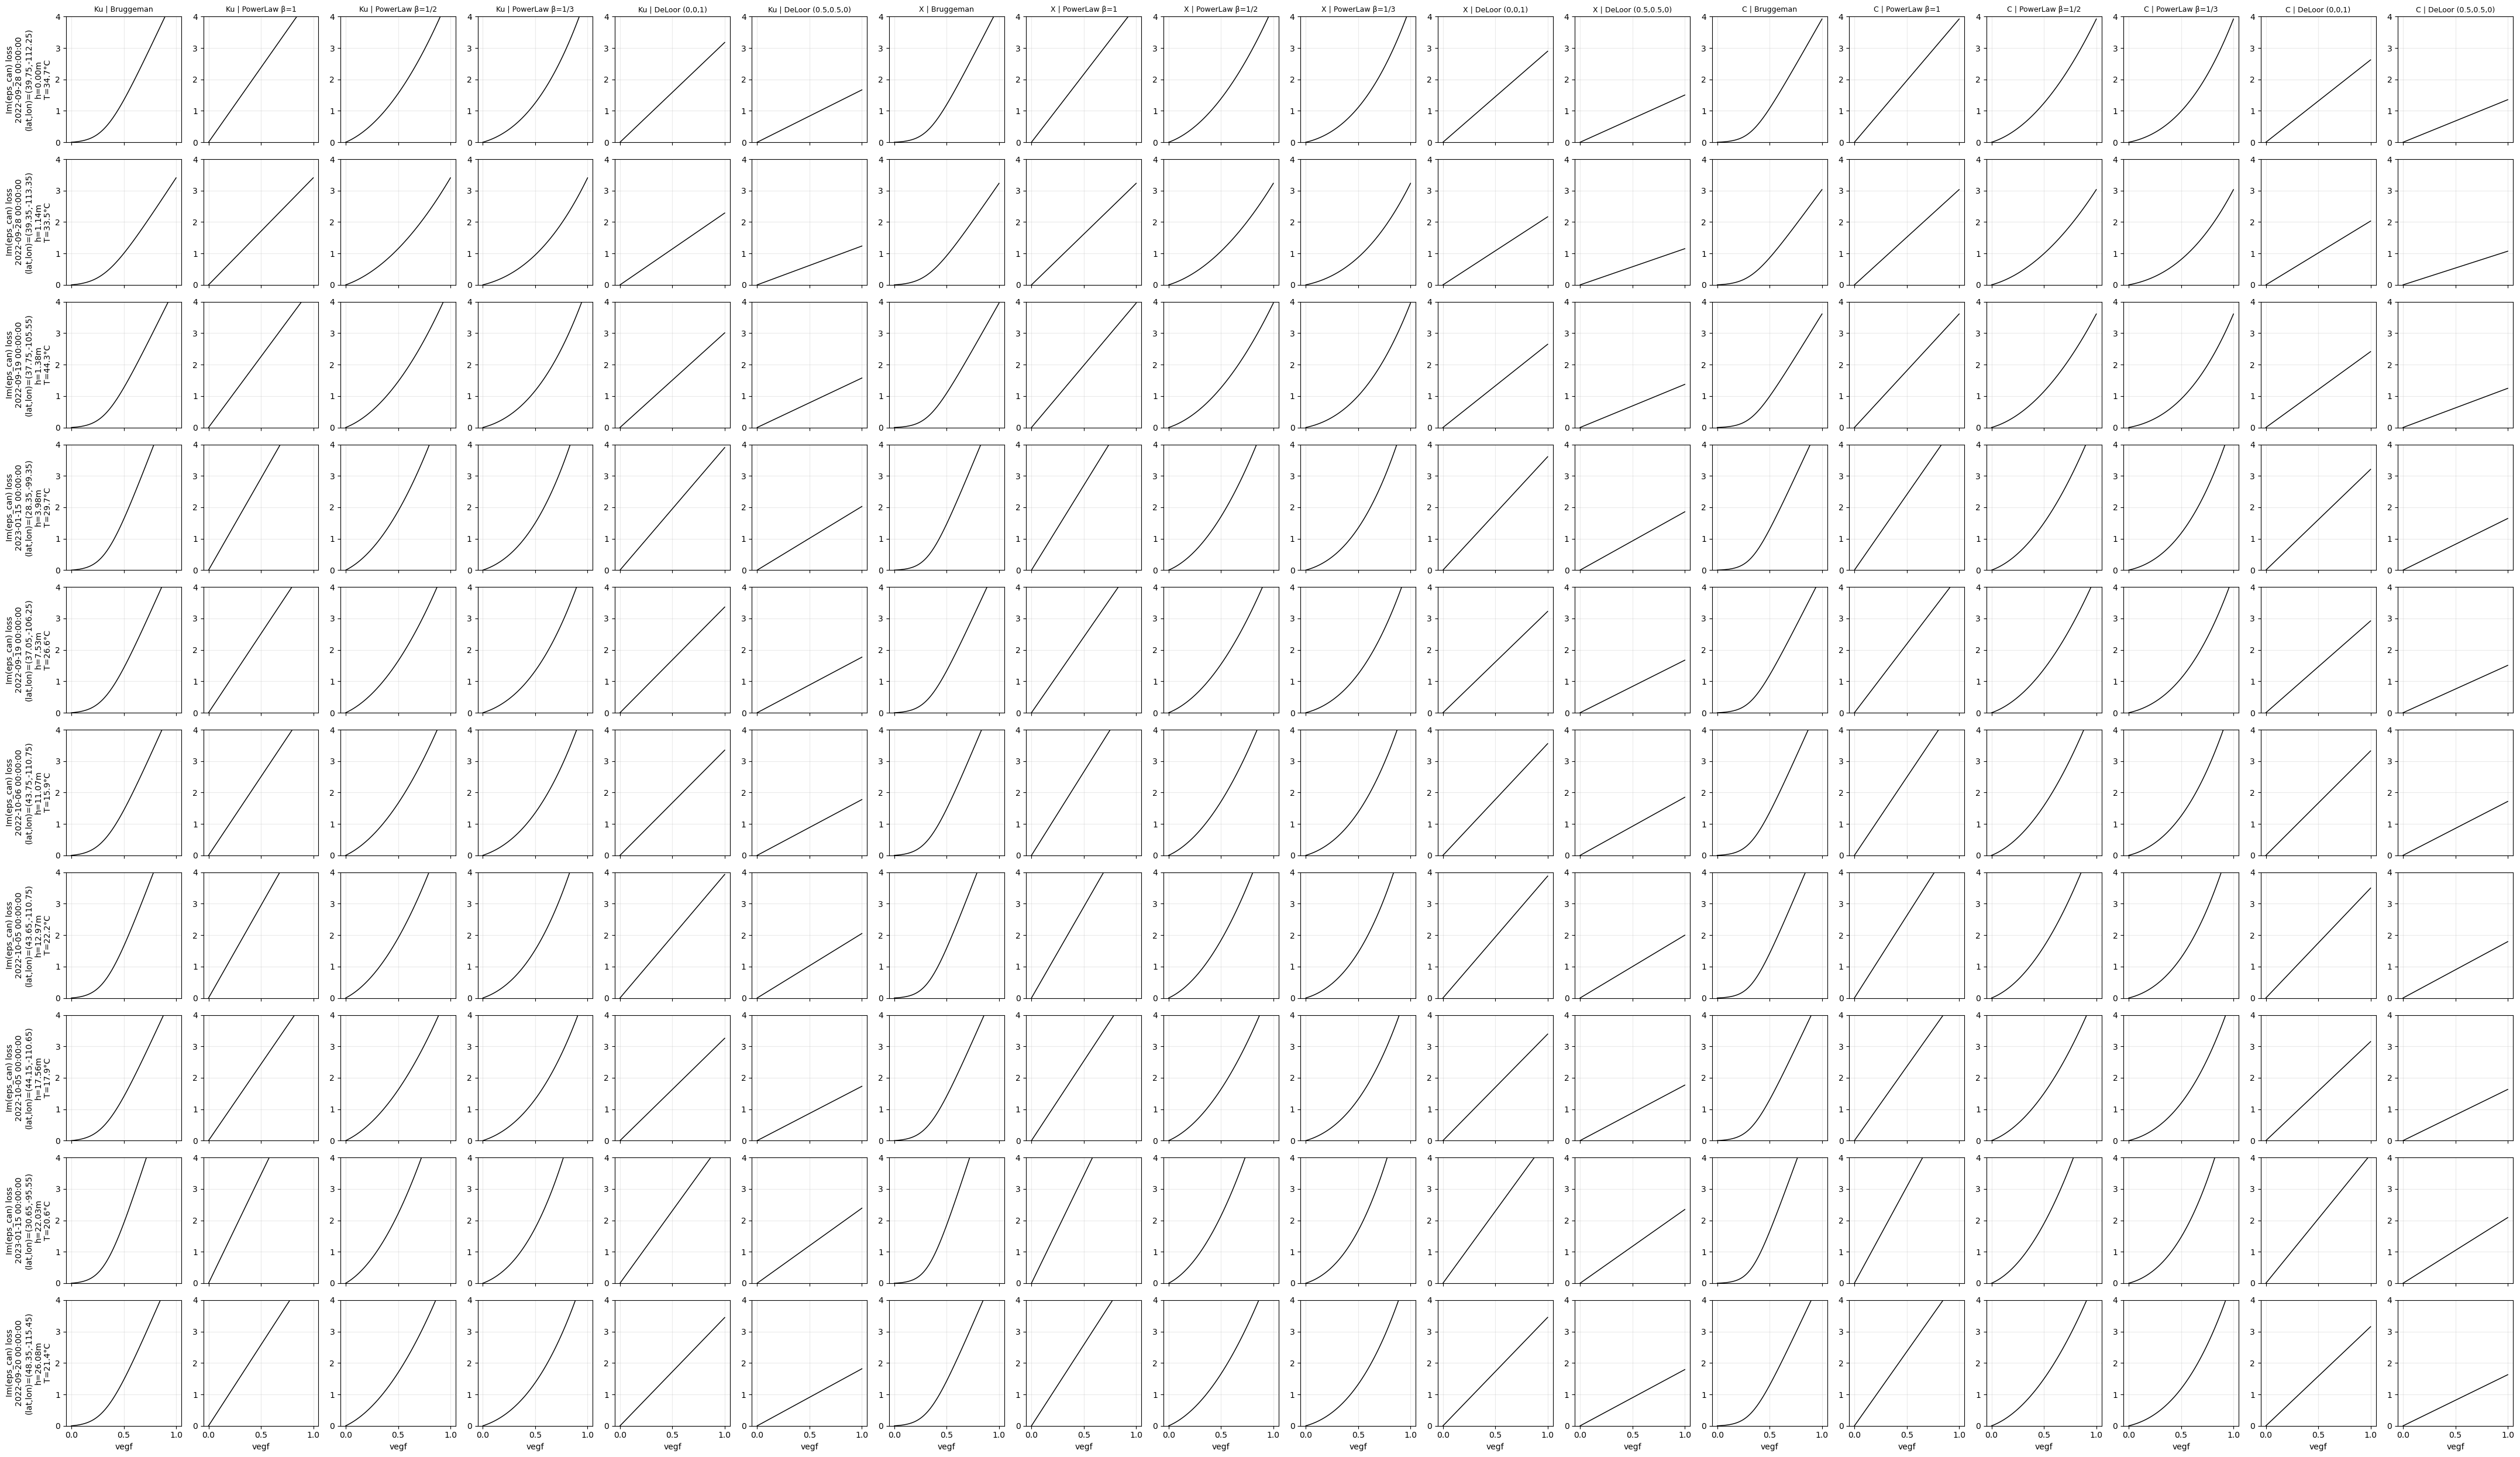

Saved figure to: D:\Python\jupyter\jupyter\LFMCRegressor\figs\epscan_imagloss_vegf_10x18_tempLst.png


In [2]:
# --- 单元：10x18 拼图（3 bands × (Bruggeman + 3 betas + 2 de loor)）
# --- 使用温度列 lst，并保存到 /figs
# --- 纵轴：冠层等效介电常数虚部（以“损耗项为正”的方式绘制：eps'' = -Im(eps_canopy)）
# --- 纵轴固定 0-4 ---

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

# =========================
# 0) 路径与导入（绕过 function.physics.__init__.py）
# =========================
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD

PHYSICS_DIR = PROJECT_ROOT / "function" / "physics"
sys.path.insert(0, str(PHYSICS_DIR))

import constant
import mixing
import vegetation_dielectric

# 输出目录（与 notebooks 平行）
FIG_DIR = PROJECT_ROOT / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 输出文件名：突出“eps_canopy 虚部(损耗项为正)”
OUT_PATH = FIG_DIR / "epscan_imagloss_vegf_10x18_tempLst.png"

# =========================
# 1) 读取 YAML（configs/physics.yaml）
# =========================
cfg_path = PROJECT_ROOT / "configs" / "physics.yaml"
with open(cfg_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

phy = cfg["physics"]
bands_hz = phy["bands_hz"]  # {"C":..., "X":..., "Ku":...}
veg_eps_model = phy["vegetation_dielectric"]["model"]

# =========================
# 2) 读取 parquet
# =========================
parquet_path = r"G:\data\Globe LFMC\processed\lfmc_base_0p1.parquet"
df = pd.read_parquet(parquet_path)

need_cols = ["row", "col", "canopy_height", "lfmc_pct", "tau_Ku_H", "tau_X_H", "tau_C_H", "lst"]
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise KeyError(f"Parquet 缺少必要列: {missing}")

# 时间列自动识别（用于标注）
time_candidates = [
    "time", "date", "datetime", "timestamp",
    "obs_time", "acq_time", "acq_datetime", "acquisition_time",
    "t", "dt"
]
time_col = next((c for c in time_candidates if c in df.columns), None)

# 三波段H极化 tau + lfmc + canopy_height + row/col + lst 均不为空
df_valid = df.dropna(subset=need_cols).copy()

# 像元ID
df_valid["pix_id"] = df_valid["row"].astype(int).astype(str) + "_" + df_valid["col"].astype(int).astype(str)

# 至少2次观测（时序像元）
pix_stat = (
    df_valid.groupby("pix_id", sort=False)
    .agg(
        n_obs=("lfmc_pct", "size"),
        h_mean=("canopy_height", "mean"),
        row=("row", "first"),
        col=("col", "first"),
    )
    .reset_index()
)
pix_stat = pix_stat[pix_stat["n_obs"] >= 2].copy()
if len(pix_stat) < 10:
    raise ValueError(f"满足'至少2次观测且三波段tau都非空且lst非空'的像元不足10个：当前 {len(pix_stat)} 个")

# =========================
# 3) 选10个代表性像元（覆盖不同冠层高度）
# =========================
pix_stat = pix_stat.sort_values(["h_mean", "n_obs"], ascending=[True, False]).reset_index(drop=True)

try:
    pix_stat["h_bin"] = pd.qcut(pix_stat["h_mean"], q=10, duplicates="drop")
except ValueError:
    pix_stat["h_bin"] = pd.cut(pix_stat["h_mean"], bins=10)

chosen = (
    pix_stat.sort_values(["h_bin", "n_obs"], ascending=[True, False])
    .groupby("h_bin", as_index=False)
    .head(1)
)

# 不足10个就按 n_obs 补齐
if len(chosen) < 10:
    remaining = pix_stat[~pix_stat["pix_id"].isin(chosen["pix_id"])].sort_values("n_obs", ascending=False)
    chosen = pd.concat([chosen, remaining.head(10 - len(chosen))], ignore_index=True)

chosen = chosen.head(10).reset_index(drop=True)

# =========================
# 4) 每像元选 1 条代表观测（有时间列则选最新）
# =========================
records = []
for _, r in chosen.iterrows():
    sub = df_valid[df_valid["pix_id"] == r["pix_id"]].copy()
    if time_col is not None:
        sub = sub.sort_values(time_col)
        rec = sub.iloc[-1]
    else:
        rec = sub.iloc[0]
    records.append(rec)

rec_df = pd.DataFrame(records).reset_index(drop=True)

# =========================
# 5) row/col -> lat/lon（0-base）
# =========================
def rowcol_to_latlon(row0, col0):
    lat = 89.95 - 0.1 * float(row0)
    lon = -179.95 + 0.1 * float(col0)
    return round(lat, 2), round(lon, 2)

# lst -> temp_c（自动判断 K/°C）
def lst_to_temp_c(lst_val: float) -> float:
    # 常见 LST 如果是 Kelvin：约 250~330；如果是 Celsius：约 -30~60
    return lst_val - 273.15 if lst_val > 200 else lst_val

# =========================
# 6) 计算 eps_canopy 并绘图（10x18），纵轴固定 0-4
# =========================
vegf = np.round(np.arange(0.0, 1.0 + 1e-12, 0.01), 2)

bands = ["Ku", "X", "C"]
mix_cases = [
    ("Bruggeman", ("bruggeman", None)),
    ("PowerLaw β=1", ("power", 1.0)),
    ("PowerLaw β=1/2", ("power", 0.5)),
    ("PowerLaw β=1/3", ("power", 1.0/3.0)),
    ("DeLoor (0,0,1)", ("deloor", (0.0, 0.0, 1.0))),
    ("DeLoor (0.5,0.5,0)", ("deloor", (0.5, 0.5, 0.0))),
]

n_rows = 10
n_cols = len(bands) * len(mix_cases)  # 18

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4*n_cols, 2.5*n_rows), sharex=True)

# 顶部列标题
col_titles = []
for b in bands:
    for m in mix_cases:
        col_titles.append(f"{b} | {m[0]}")
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=9)

for i in range(n_rows):
    rec = rec_df.iloc[i]
    row0 = int(rec["row"])
    col0 = int(rec["col"])
    lat, lon = rowcol_to_latlon(row0, col0)

    lfmc = float(rec["lfmc_pct"])
    hveg = float(rec["canopy_height"])

    lst_val = float(rec["lst"])
    temp_c = lst_to_temp_c(lst_val)

    if time_col is not None:
        tstr = str(pd.to_datetime(rec[time_col]))
    else:
        tstr = "NA"

    # 每行第一列 y轴：eps''(canopy) + 文字（时间/经纬度/冠层高/温度）
    ylab = (
        "Im(eps_can) loss\n"
        f"{tstr}\n(lat,lon)=({lat},{lon})\n"
        f"h={hveg:.2f}m\nT={temp_c:.1f}°C"
    )

    for bi, band in enumerate(bands):
        freq_hz = float(bands_hz[band])
        freq_ghz = freq_hz / 1e9

        # LFMC -> eps_veg（complex），传入温度（自由水介电常数随温度变）
        eps_veg = vegetation_dielectric.epsilon_veg_from_lfmc(
            lfmc_pct=np.array([lfmc], dtype=float),
            f_ghz=np.array([freq_ghz], dtype=float),
            model=veg_eps_model,
            temp_c=np.array([temp_c], dtype=float),
        )[0]

        for mi, (mname, mcase) in enumerate(mix_cases):
            ax = axes[i, bi*len(mix_cases) + mi]
            tag, param = mcase

            if tag == "bruggeman":
                # 延续法（warm start）避免解跳变
                eps_can = np.empty_like(vegf, dtype=np.complex128)
                init = 1.2 + 0.01j
                for k, v in enumerate(vegf):
                    init = mixing.bruggeman_mix(
                        eps_components=np.array([1.0 + 0.0j, eps_veg], dtype=np.complex128),
                        fracs=np.array([1.0 - float(v), float(v)], dtype=float),
                        init=init
                    )
                    eps_can[k] = init

            elif tag == "power":
                beta = float(param)
                eps_can = mixing.power_law_air_veg(eps_veg=eps_veg, vegf=vegf, beta=beta)

            else:  # deloor
                Aa, Ab, Ac = param
                eps_can = np.array([
                    mixing.de_loor_pvs_forward(
                        eps_host=1.0 + 0.0j,
                        eps_incl=eps_veg,
                        vegf=float(v),
                        Aa=float(Aa), Ab=float(Ab), Ac=float(Ac),
                        eps_star=None
                    )
                    for v in vegf
                ], dtype=np.complex128)

            # 纵轴：冠层等效介电常数的“损耗项”（正数）
            # Ulaby 约定 eps = eps' - j eps'' => imag(eps) <= 0，因此 eps'' = -imag(eps)
            y = -np.imag(eps_can)
            y = np.maximum(y, 0.0)  # 数值保护

            ax.plot(vegf, y, color="k", linewidth=1.05)

            ax.set_ylim(0, 4)

            if i == n_rows - 1:
                ax.set_xlabel("vegf")

            if (bi*len(mix_cases) + mi) == 0:
                ax.set_ylabel(ylab)
            else:
                ax.set_ylabel("")

            ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {OUT_PATH}")


### 等效冠层介电常数平方根的虚部

C:\Users\Ronin\AppData\Local\Temp\ipykernel_5132\2716069683.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("h_bin", as_index=False)


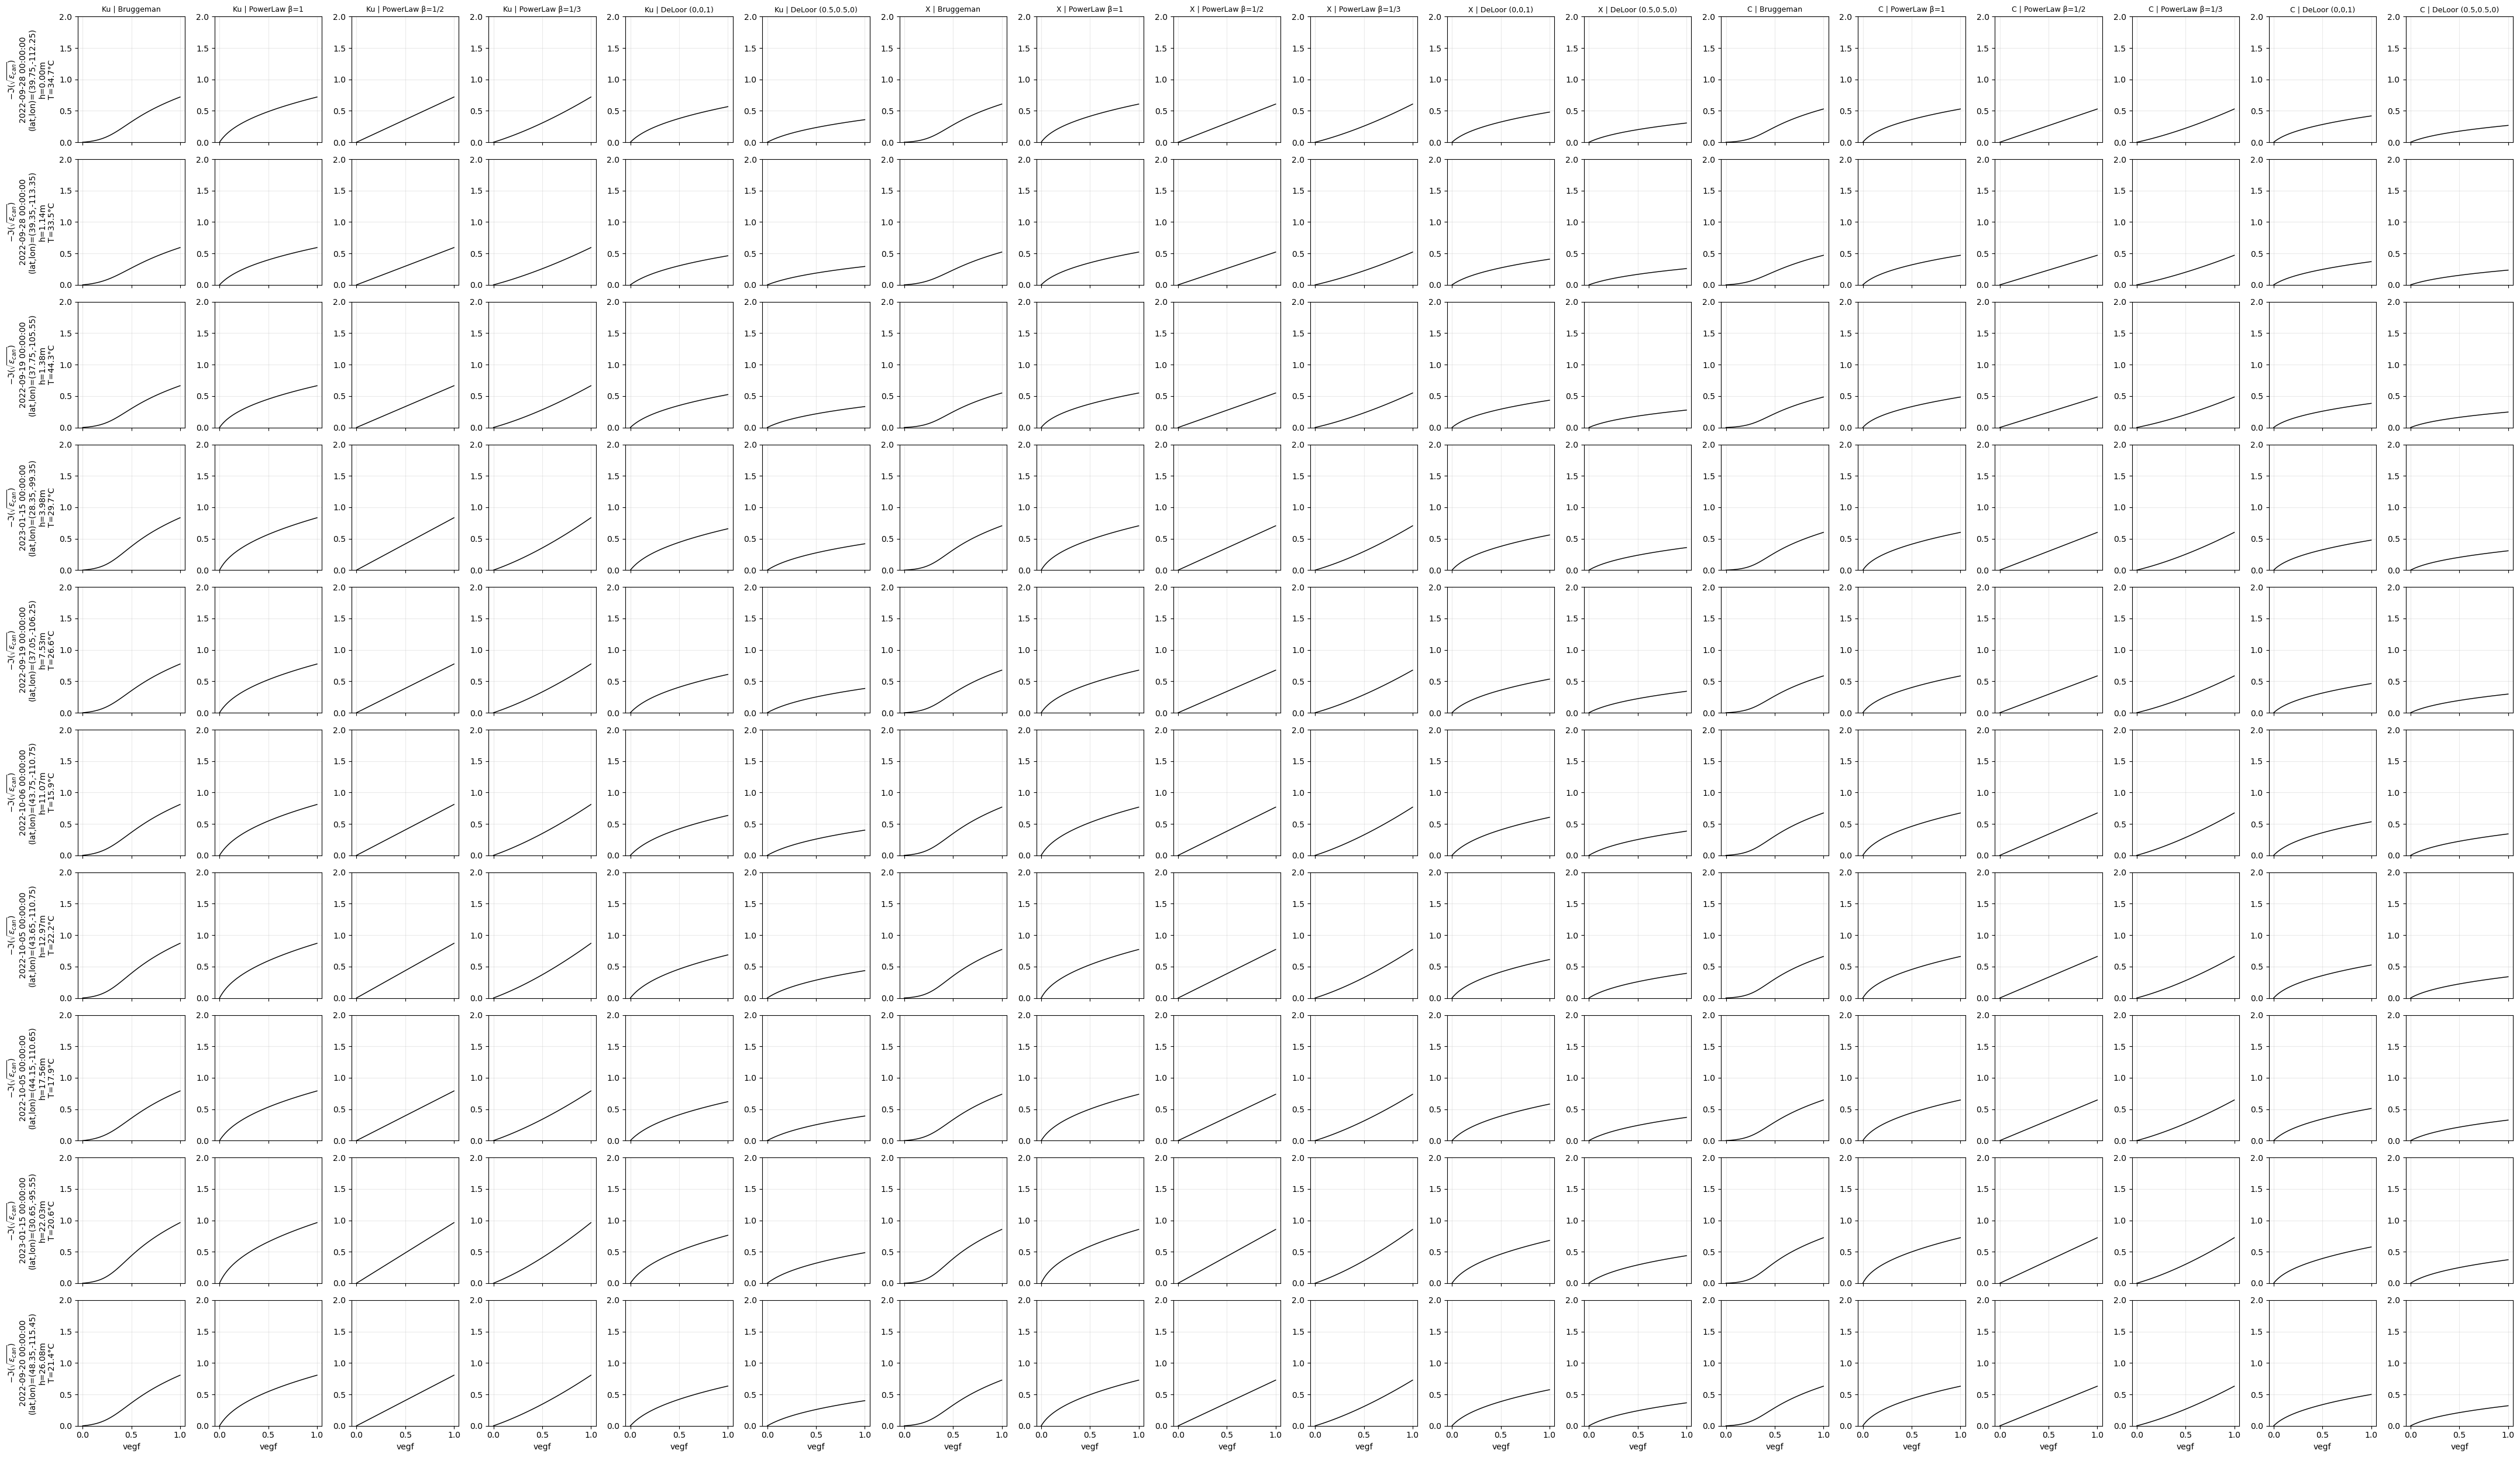

Saved figure to: D:\Python\jupyter\jupyter\LFMCRegressor\figs\epscan_sqrt_imagloss_vegf_10x18_tempLst.png


In [3]:
# --- 单元：10x18 拼图（3 bands × (Bruggeman + 3 betas + 2 de loor)）
# --- 使用温度列 lst
# --- 纵轴：-Im(sqrt(eps_canopy))（最终参与到 τ/VOD 的介电项）
# --- 纵轴固定 0-2（你可以按需要改成 0-4 或自动）并保存到 /figs ---

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

# =========================
# 0) 路径与导入（绕过 function.physics.__init__.py）
# =========================
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD

PHYSICS_DIR = PROJECT_ROOT / "function" / "physics"
sys.path.insert(0, str(PHYSICS_DIR))

import constant
import mixing
import vegetation_dielectric

# 输出目录（与 notebooks 平行）
FIG_DIR = PROJECT_ROOT / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = FIG_DIR / "epscan_sqrt_imagloss_vegf_10x18_tempLst.png"

# =========================
# 1) 读取 YAML（configs/physics.yaml）
# =========================
cfg_path = PROJECT_ROOT / "configs" / "physics.yaml"
with open(cfg_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

phy = cfg["physics"]
bands_hz = phy["bands_hz"]  # {"C":..., "X":..., "Ku":...}
veg_eps_model = phy["vegetation_dielectric"]["model"]

# =========================
# 2) 读取 parquet
# =========================
parquet_path = r"G:\data\Globe LFMC\processed\lfmc_base_0p1.parquet"
df = pd.read_parquet(parquet_path)

need_cols = ["row", "col", "canopy_height", "lfmc_pct", "tau_Ku_H", "tau_X_H", "tau_C_H", "lst"]
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise KeyError(f"Parquet 缺少必要列: {missing}")

# 时间列自动识别（用于标注）
time_candidates = [
    "time", "date", "datetime", "timestamp",
    "obs_time", "acq_time", "acq_datetime", "acquisition_time",
    "t", "dt"
]
time_col = next((c for c in time_candidates if c in df.columns), None)

# 三波段H极化 tau + lfmc + canopy_height + row/col + lst 均不为空
df_valid = df.dropna(subset=need_cols).copy()

# 像元ID
df_valid["pix_id"] = df_valid["row"].astype(int).astype(str) + "_" + df_valid["col"].astype(int).astype(str)

# 至少2次观测（时序像元）
pix_stat = (
    df_valid.groupby("pix_id", sort=False)
    .agg(
        n_obs=("lfmc_pct", "size"),
        h_mean=("canopy_height", "mean"),
        row=("row", "first"),
        col=("col", "first"),
    )
    .reset_index()
)
pix_stat = pix_stat[pix_stat["n_obs"] >= 2].copy()
if len(pix_stat) < 10:
    raise ValueError(f"满足'至少2次观测且三波段tau都非空且lst非空'的像元不足10个：当前 {len(pix_stat)} 个")

# =========================
# 3) 选10个代表性像元（覆盖不同冠层高度）
# =========================
pix_stat = pix_stat.sort_values(["h_mean", "n_obs"], ascending=[True, False]).reset_index(drop=True)

try:
    pix_stat["h_bin"] = pd.qcut(pix_stat["h_mean"], q=10, duplicates="drop")
except ValueError:
    pix_stat["h_bin"] = pd.cut(pix_stat["h_mean"], bins=10)

chosen = (
    pix_stat.sort_values(["h_bin", "n_obs"], ascending=[True, False])
    .groupby("h_bin", as_index=False)
    .head(1)
)

# 不足10个就按 n_obs 补齐
if len(chosen) < 10:
    remaining = pix_stat[~pix_stat["pix_id"].isin(chosen["pix_id"])].sort_values("n_obs", ascending=False)
    chosen = pd.concat([chosen, remaining.head(10 - len(chosen))], ignore_index=True)

chosen = chosen.head(10).reset_index(drop=True)

# =========================
# 4) 每像元选 1 条代表观测（有时间列则选最新）
# =========================
records = []
for _, r in chosen.iterrows():
    sub = df_valid[df_valid["pix_id"] == r["pix_id"]].copy()
    if time_col is not None:
        sub = sub.sort_values(time_col)
        rec = sub.iloc[-1]
    else:
        rec = sub.iloc[0]
    records.append(rec)

rec_df = pd.DataFrame(records).reset_index(drop=True)

# =========================
# 5) row/col -> lat/lon（0-base）
# =========================
def rowcol_to_latlon(row0, col0):
    lat = 89.95 - 0.1 * float(row0)
    lon = -179.95 + 0.1 * float(col0)
    return round(lat, 2), round(lon, 2)

# lst -> temp_c（自动判断 K/°C；你已确认 lst 是 K）
def lst_to_temp_c(lst_val: float) -> float:
    return lst_val - 273.15 if lst_val > 200 else lst_val

# =========================
# 6) 计算 loss_term = -Im(sqrt(eps_can)) 并绘图（10x18）
# =========================
vegf = np.round(np.arange(0.0, 1.0 + 1e-12, 0.01), 2)

bands = ["Ku", "X", "C"]
mix_cases = [
    ("Bruggeman", ("bruggeman", None)),
    ("PowerLaw β=1", ("power", 1.0)),
    ("PowerLaw β=1/2", ("power", 0.5)),
    ("PowerLaw β=1/3", ("power", 1.0/3.0)),
    ("DeLoor (0,0,1)", ("deloor", (0.0, 0.0, 1.0))),
    ("DeLoor (0.5,0.5,0)", ("deloor", (0.5, 0.5, 0.0))),
]

n_rows = 10
n_cols = len(bands) * len(mix_cases)  # 18

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4*n_cols, 2.5*n_rows), sharex=True)

# 顶部列标题
col_titles = []
for b in bands:
    for m in mix_cases:
        col_titles.append(f"{b} | {m[0]}")
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=9)

for i in range(n_rows):
    rec = rec_df.iloc[i]
    row0 = int(rec["row"])
    col0 = int(rec["col"])
    lat, lon = rowcol_to_latlon(row0, col0)

    lfmc = float(rec["lfmc_pct"])
    hveg = float(rec["canopy_height"])

    lst_val = float(rec["lst"])
    temp_c = lst_to_temp_c(lst_val)

    if time_col is not None:
        tstr = str(pd.to_datetime(rec[time_col]))
    else:
        tstr = "NA"

    ylab = (
        r"$-\Im(\sqrt{\varepsilon_{can}})$" + "\n"
        f"{tstr}\n(lat,lon)=({lat},{lon})\n"
        f"h={hveg:.2f}m\nT={temp_c:.1f}°C"
    )

    for bi, band in enumerate(bands):
        freq_hz = float(bands_hz[band])
        freq_ghz = freq_hz / 1e9

        eps_veg = vegetation_dielectric.epsilon_veg_from_lfmc(
            lfmc_pct=np.array([lfmc], dtype=float),
            f_ghz=np.array([freq_ghz], dtype=float),
            model=veg_eps_model,
            temp_c=np.array([temp_c], dtype=float),
        )[0]

        for mi, (mname, mcase) in enumerate(mix_cases):
            ax = axes[i, bi*len(mix_cases) + mi]
            tag, param = mcase

            if tag == "bruggeman":
                # 延续法（warm start）避免解跳变
                eps_can = np.empty_like(vegf, dtype=np.complex128)
                init = 1.2 + 0.01j
                for k, v in enumerate(vegf):
                    init = mixing.bruggeman_mix(
                        eps_components=np.array([1.0 + 0.0j, eps_veg], dtype=np.complex128),
                        fracs=np.array([1.0 - float(v), float(v)], dtype=float),
                        init=init
                    )
                    eps_can[k] = init

            elif tag == "power":
                beta = float(param)
                eps_can = mixing.power_law_air_veg(eps_veg=eps_veg, vegf=vegf, beta=beta)

            else:  # deloor
                Aa, Ab, Ac = param
                eps_can = np.array([
                    mixing.de_loor_pvs_forward(
                        eps_host=1.0 + 0.0j,
                        eps_incl=eps_veg,
                        vegf=float(v),
                        Aa=float(Aa), Ab=float(Ab), Ac=float(Ac),
                        eps_star=None
                    )
                    for v in vegf
                ], dtype=np.complex128)

            # principal sqrt，然后取损耗项（保证非负）
            sqrt_eps = np.sqrt(eps_can)
            loss_term = -np.imag(sqrt_eps)
            loss_term = np.maximum(loss_term, 0.0)

            ax.plot(vegf, loss_term, color="k", linewidth=1.05)

            # 你可以按需要改成 0-4；这里先给个更常见的范围，避免全是贴顶
            ax.set_ylim(0, 2)

            if i == n_rows - 1:
                ax.set_xlabel("vegf")

            if (bi*len(mix_cases) + mi) == 0:
                ax.set_ylabel(ylab)
            else:
                ax.set_ylabel("")

            ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {OUT_PATH}")


## 主程序

## 1) 准备训练样本 DataFrame

你最终会用：
- lfmc_site_day.parquet（第二部分输出）
- 与 VOD 进行匹配后得到 vod_obs（第四部分才做）
- hveg_m 现在可以先用常数（比如 10m）或站点提供值

本阶段先用一个 toy dataframe 来验证代码通路。


In [ ]:
# toy data: 100 samples
n = 200
rng = np.random.default_rng(42)

df_train = pd.DataFrame({
    "lfmc_pct": rng.uniform(50, 200, size=n),
    "hveg_m": rng.uniform(1, 20, size=n),
    "band": rng.choice(["C","X","Ku"], size=n),
})

# make a synthetic "observed" VOD (for debug) by adding noise
# later you replace df_train["vod_obs"] with real VOD
df_train["vod_obs"] = rng.normal(0.8, 0.2, size=n)

df_train.head()


## 2) 拟合最小参数：a,b（每band）+ delta + (k_re,k_im)


In [ ]:
p_best, report = fit_physics_model(df_train, cfg)
report


In [ ]:
df_train["vod_pred"] = predict_vod_dataframe(df_train, cfg["physics"], p_best)
resid = df_train["vod_pred"] - df_train["vod_obs"]

plt.figure(figsize=(5,4))
plt.scatter(df_train["vod_obs"], df_train["vod_pred"], s=8)
plt.xlabel("VOD obs")
plt.ylabel("VOD pred")
plt.title("Physics model fit (toy)")
plt.show()

plt.figure(figsize=(6,3))
plt.hist(resid, bins=40)
plt.title("Residual histogram")
plt.show()
